> - $\theta_{jn}$ and inclination angle are currently not distinguished (which is very much not true).
> - Magnification factors not yet included! Idk why I'm procrastinating on this

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.cosmology import Planck18, z_at_value
import scipy.integrate as integrate
from bilby.gw.waveform_generator import WaveformGenerator
from bilby.gw.utils import inner_product
from bilby.gw.detector.psd import PowerSpectralDensity
from bilby.gw.source import lal_binary_black_hole
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters
from bilby.gw.detector import InterferometerList
from pycbc.conversions import mchirp_from_mass1_mass2, mass1_from_mchirp_q, mass2_from_mchirp_q

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


# Lensing-related parameters
It's assumed that the source position ($\beta$) and image positions ($\theta^\pm$) are small compared to the deflection angles ($\hat\alpha^\pm$).

$$\iota=\iota(\theta_{jn}, m_1, m_2, a_1, a_2, tilt_1, tilt_2, \phi_{12}, \phi_{jl})$$
$$\hat\alpha^\pm\approx\sqrt{2}\left(\frac{R}{R_s}\right)^{-1/2}$$
$$\cos\phi_{proj}=\frac{\sin\iota\sin\phi_L}{\sqrt{\cos^2\iota+\sin^2\iota\sin^2\phi_L}}$$
$$\Delta z\approx2\frac{R}{R_s}\cos\phi_{proj}$$
$$\cos\iota^\pm\approx\cos\iota\mp\frac{\sin\iota\cos\iota\cos\phi_L}{\sqrt{\cos^2\iota+\sin^2\iota\sin^2\phi_L}}\hat\alpha^\pm$$
$$\cos\phi_c^\pm\approx\cos\phi_c\pm\frac{\sin\phi_c\csc\iota\sin\phi_L}{\sqrt{\cos^2\iota+\sin^2\iota\sin^2\phi_L}}\hat\alpha^\pm$$
$$\cos\psi^\pm\approx\cos\psi\mp \frac{\cot (\iota ) \sin (\psi ) \sin (\phi_\text{L})}{\sqrt{\sin ^2(\iota ) \sin ^2(\phi_\text{L})+\cos ^2(\iota )}}\hat\alpha^\pm$$

In [2]:
def get_iota(theta_jn, mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12, phi_jl): # inclination angle from theta_jn
    return theta_jn # need to fix this!!! use the conversion from lalsim?

def get_alpha_hat(R_orbit): # deflection angle
    # R is radius of BBH orbit about AGN in units of Schwarzschild radii
    return np.sqrt(2) * R_orbit ** (- 1 / 2)

def get_cos_phi_proj(iota, phi_L): # projection from orbital plane onto lensing plane
    return np.sin(iota) * np.sin(phi_L) / (np.sqrt(np.cos(iota) ** 2 + np.sin(iota) ** 2 * np.sin(phi_L) ** 2))

def get_delta_z(R_orbit, cos_phi_proj): # redshift difference between the unlensed waveform and the image
    return 2 * cos_phi_proj / R_orbit, - 2 * cos_phi_proj / R_orbit

def get_image_theta_jn(iota, phi_L, alpha_hat): # angle between total angular momentum and observer position
    # the formula used here was derived for inclination angle, not theta_jn! need to fix this!!
    correction = alpha_hat * (np.sin(iota) * np.cos(iota) * np.cos(phi_L)) / np.sqrt(np.sin(iota) ** 2 * np.sin(phi_L) ** 2 + np.cos(iota) ** 2)
    return np.arccos(np.cos(iota) - correction), np.arccos(np.cos(iota) + correction)

def get_image_phase(iota, phi_L, phase, alpha_hat): # coalescence phase
    correction = alpha_hat * (np.sin(phase) * (1 / np.sin(iota)) * np.sin(phi_L)) / np.sqrt(np.sin(iota) ** 2 * np.sin(phi_L) ** 2 + np.cos(iota) ** 2)
    return np.arccos(np.cos(phase) + correction), np.arccos(np.cos(phase) - correction)

def get_image_psi(iota, phi_L, psi, alpha_hat): # polarization angle
    correction = alpha_hat * ((1 / np.tan(iota)) * np.sin(phi_L) * np.sin(psi)) / np.sqrt(np.sin(iota) ** 2 * np.sin(phi_L) ** 2 + np.cos(iota) ** 2)
    return np.arccos(np.cos(psi) - correction), np.arccos(np.cos(psi) + correction)

# maybe combine all the above into one function that returns a dictionary?

# Mismatch definition

$$\text{mismatch}=1-\mathcal{M}\equiv\frac{\langle h_1-h_2, h_1-h_2\rangle}{2\left(\langle h_1,h_1\rangle +\langle h_2,h_2\rangle\right)}$$

In [3]:
def mismatch(h1, h2, frequencies, psd):
    return inner_product(h1-h2, h1-h2, frequencies, psd) / (2 * (inner_product(h1, h1, frequencies, psd) + inner_product(h2, h2, frequencies, psd)))

# Source models

In [4]:
# source model for image 1, obtained from unlensed parameters
def image_1_from_source(frequency_array, mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12, phi_jl, 
                        luminosity_distance, theta_jn, phase,
                        phi_L, R_orbit, **kwargs):
    iota_unlensed = get_iota(theta_jn, mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12, phi_jl)
    alpha_hat = get_alpha_hat(R_orbit)
    theta_jn_1 = get_image_theta_jn(iota_unlensed, phi_L, alpha_hat)[0]
    phase_1 = get_image_phase(iota_unlensed, phi_L, phase, alpha_hat)[0]
    cos_phi_proj = get_cos_phi_proj(iota_unlensed, phi_L)

    # doppler effect is treated as a change in the effective chirp mass
    chirp_mass = mchirp_from_mass1_mass2(mass_1, mass_2)
    q = mass_1 / mass_2
    z = z_at_value(Planck18.luminosity_distance, luminosity_distance * u.Mpc)
    delta_z = get_delta_z(R_orbit, cos_phi_proj)[0]
    chirp_mass_1 = ((1 + z) / (1 + z + delta_z)) ** (8/5) * chirp_mass # need to double check if this formula is correct
    mass_1_1 = mass1_from_mchirp_q(chirp_mass_1, q)
    mass_2_1 = mass2_from_mchirp_q(chirp_mass_1, q)
    
    print("\ndeflection angle =", alpha_hat,
          "\ncos_phi_proj =", cos_phi_proj,
          "\nimage 1 chirp mass =", mchirp_from_mass1_mass2(mass_1_1, mass_2_1),
          "\nimage 1 theta_jn =", theta_jn_1,
          "\nimage 1 phase =", phase_1)

    wf = lal_binary_black_hole(
        frequency_array=frequency_array, mass_1=mass_1_1, mass_2=mass_2_1,
        luminosity_distance=luminosity_distance, theta_jn=theta_jn_1, phase=phase_1,
        a_1=a_1, a_2=a_2, tilt_1=tilt_1, tilt_2=tilt_2, phi_12=phi_12,
        phi_jl=phi_jl, **kwargs)
    hp = wf['plus']
    hc = wf['cross']

    return {"plus": hp, "cross": hc}

In [5]:
# source model for image 2, obtained from unlensed parameters
def image_2_from_source(frequency_array, mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12, phi_jl, 
                        luminosity_distance, theta_jn, phase, 
                        R_orbit, phi_L, **kwargs):
    iota = get_iota(theta_jn, mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12, phi_jl)
    alpha_hat = get_alpha_hat(R_orbit)
    theta_jn_2 = get_image_theta_jn(iota, phi_L, alpha_hat)[1]
    phase_2 = get_image_phase(iota, phi_L, phase, alpha_hat)[1]
    cos_phi_proj = get_cos_phi_proj(iota, phi_L)

    # doppler effect is treated as a change in the effective chirp mass
    chirp_mass = mchirp_from_mass1_mass2(mass_1, mass_2)
    q = mass_1 / mass_2
    z = z_at_value(Planck18.luminosity_distance, luminosity_distance * u.Mpc)
    delta_z = get_delta_z(R_orbit, cos_phi_proj)[1]
    chirp_mass_2 = ((1 + z) / (1 + z + delta_z)) ** (8/5) * chirp_mass # need to double check if this formula is correct
    mass_1_2 = mass1_from_mchirp_q(chirp_mass_2, q)
    mass_2_2 = mass2_from_mchirp_q(chirp_mass_2, q)

    print("\ndeflection angle =", alpha_hat,
          "\ncos_phi_proj =", cos_phi_proj,
          "\nimage 2 chirp mass =", mchirp_from_mass1_mass2(mass_1_2, mass_2_2),
          "\nimage 2 theta_jn =", theta_jn_2,
          "\nimage 2 phase =", phase_2)

    wf = lal_binary_black_hole(
        frequency_array=frequency_array, mass_1=mass_1_2, mass_2=mass_2_2,
        luminosity_distance=luminosity_distance, theta_jn=theta_jn_2, phase=phase_2,
        a_1=a_1, a_2=a_2, tilt_1=tilt_1, tilt_2=tilt_2, phi_12=phi_12,
        phi_jl=phi_jl, **kwargs)
    hp = wf['plus']
    hc = wf['cross']

    return {"plus": hp, "cross": hc}

# Parameters

In [6]:
parameters = dict(
    mass_1=60,
    mass_2=30,
    a_1=0.4,
    a_2=0.3,
    tilt_1=0.5,
    tilt_2=1.0,
    phi_12=1.7,
    phi_jl=0.3,
    luminosity_distance=400,
    theta_jn=1.02*np.pi/2,
    phase=1.3,
    psi=2,
    geocent_time=0,
    ra=1.375,
    dec=-1.2108,
    R_orbit=20,
    phi_L=0.98*np.pi
    )
unlensed_parameters = parameters.copy()
image_1_parameters = parameters.copy()
image_2_parameters = parameters.copy()

# calculate deflection angle from R_orbit
alpha_hat = get_alpha_hat(unlensed_parameters["R_orbit"])

In [7]:
duration = 16
sampling_frequency = 4096
waveform_arguments = dict(
    waveform_approximant="IMRPhenomPv2",
    reference_frequency=20,
    minimum_frequency=20,
)

frequencies = np.arange(0, sampling_frequency/2+1e-5, 1/duration)
psd = PowerSpectralDensity(psd_file='aLIGO_ZERO_DET_high_P_psd.txt')

# Generate & inject waveforms

In [8]:
# set up waveform generators for unlensed waveform and the two images
wf_generator_unlensed = WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    start_time=parameters["geocent_time"]-duration,
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
)
wf_generator_1 = WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    start_time=parameters["geocent_time"]-duration,
    frequency_domain_source_model=image_1_from_source,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
)
wf_generator_2 = WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    start_time=parameters["geocent_time"]-duration,
    frequency_domain_source_model=image_2_from_source,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments,
)

# set up interferometers
ifos = InterferometerList(["H1", "L1"])
ifos.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency,
    duration=duration,
    start_time=parameters["geocent_time"]-duration,
)

23:09 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
23:09 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.image_1_from_source
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
23:09 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.image_2_from_source
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


In [9]:
# inject unlensed waveform since it's independent of phi_L
injection_unlensed = ifos.inject_signal(
    waveform_generator=wf_generator_unlensed, parameters=unlensed_parameters
)
# get strains from H1
unlensed_H1_hp = injection_unlensed[0]["plus"]
unlensed_H1_hc = injection_unlensed[0]["cross"]

23:09 bilby INFO    : Injected signal in H1:
23:09 bilby INFO    :   optimal SNR = 44.15
23:09 bilby INFO    :   matched filter SNR = 42.22+0.79j
23:09 bilby INFO    :   mass_1 = 60
23:09 bilby INFO    :   mass_2 = 30
23:09 bilby INFO    :   a_1 = 0.4
23:09 bilby INFO    :   a_2 = 0.3
23:09 bilby INFO    :   tilt_1 = 0.5
23:09 bilby INFO    :   tilt_2 = 1.0
23:09 bilby INFO    :   phi_12 = 1.7
23:09 bilby INFO    :   phi_jl = 0.3
23:09 bilby INFO    :   luminosity_distance = 400
23:09 bilby INFO    :   theta_jn = 1.6022122533307945
23:09 bilby INFO    :   phase = 1.3
23:09 bilby INFO    :   psi = 2
23:09 bilby INFO    :   geocent_time = 0
23:09 bilby INFO    :   ra = 1.375
23:09 bilby INFO    :   dec = -1.2108
23:09 bilby INFO    :   R_orbit = 20
23:09 bilby INFO    :   phi_L = 3.078760800517997
23:09 bilby INFO    : Injected signal in L1:
23:09 bilby INFO    :   optimal SNR = 31.45
23:09 bilby INFO    :   matched filter SNR = 29.33+0.29j
23:09 bilby INFO    :   mass_1 = 60
23:09 bilby

In [10]:
phi_Ls = np.linspace(np.pi-1, np.pi+1, 100)
mismatches_unlensed_image_1 = []
mismatches_unlensed_image_2 = []
mismatches_image1_image_2 = []

for phi_L in phi_Ls:
    # prepare image parameters
    image_1_parameters["phi_L"] = phi_L
    image_2_parameters["phi_L"] = phi_L

    # calculate image polarization angles
    psi_1 = get_image_psi(image_1_parameters["theta_jn"], image_1_parameters["phi_L"], image_1_parameters["psi"], alpha_hat)[0]
    psi_2 = get_image_psi(image_2_parameters["theta_jn"], image_2_parameters["phi_L"], image_2_parameters["psi"], alpha_hat)[1]
    print("image 1 psi =", psi_1,
        "\nimage 2 psi =", psi_2)
    image_1_parameters["psi"] = psi_1
    image_2_parameters["psi"] = psi_2

    # inject parameters
    injection_1 = ifos.inject_signal(
        waveform_generator=wf_generator_1, parameters=image_1_parameters
    )
    injection_2 = ifos.inject_signal(
        waveform_generator=wf_generator_2, parameters=image_2_parameters
    )

    # get strains from H1
    image_1_H1_hp = injection_1[0]["plus"]
    image_1_H1_hc = injection_1[0]["cross"]
    image_2_H1_hp = injection_2[0]["plus"]
    image_2_H1_hc = injection_2[0]["cross"]

    # calculate mismatches
    mm_unlensed_image1_hp = mismatch(unlensed_H1_hp, image_1_H1_hp, frequencies, psd)
    mm_unlensed_image1_hc = mismatch(unlensed_H1_hc, image_1_H1_hc, frequencies, psd)
    mm_unlensed_image1_net = (mm_unlensed_image1_hp + mm_unlensed_image1_hc) / 2
    mismatches_unlensed_image_1.append(mm_unlensed_image1_net)

    mm_unlensed_image2_hp = mismatch(unlensed_H1_hp, image_2_H1_hp, frequencies, psd)
    mm_unlensed_image2_hc = mismatch(unlensed_H1_hc, image_2_H1_hc, frequencies, psd)
    mm_unlensed_image2_net = (mm_unlensed_image2_hp + mm_unlensed_image2_hc) / 2
    mismatches_unlensed_image_2.append(mm_unlensed_image2_net)

    mm_image1_image2_hp = mismatch(image_1_H1_hp, image_2_H1_hp, frequencies, psd)
    mm_image1_image2_hc = mismatch(image_1_H1_hc, image_2_H1_hc, frequencies, psd)
    mm_image1_image2_net = (mm_image1_image2_hp + mm_image1_image2_hc) / 2
    mismatches_image1_image_2.append(mm_image1_image2_net)

23:09 bilby INFO    : Injected signal in H1:
23:09 bilby INFO    :   optimal SNR = 39.76
23:09 bilby INFO    :   matched filter SNR = 25.21+20.48j
23:09 bilby INFO    :   mass_1 = 60
23:09 bilby INFO    :   mass_2 = 30


image 1 psi = 1.9900864889085326 
image 2 psi = 2.009958695953606

deflection angle = 0.31622776601683794 
cos_phi_proj = 0.9993033361771558 
image 1 chirp mass = 31.70221843438508 
image 1 theta_jn = 1.6085895153496914 
image 1 phase = 0.9614993050546325


23:09 bilby INFO    :   a_1 = 0.4
23:09 bilby INFO    :   a_2 = 0.3
23:09 bilby INFO    :   tilt_1 = 0.5
23:09 bilby INFO    :   tilt_2 = 1.0
23:09 bilby INFO    :   phi_12 = 1.7
23:09 bilby INFO    :   phi_jl = 0.3
23:09 bilby INFO    :   luminosity_distance = 400
23:09 bilby INFO    :   theta_jn = 1.6022122533307945
23:09 bilby INFO    :   phase = 1.3
23:09 bilby INFO    :   psi = 1.9900864889085326
23:09 bilby INFO    :   geocent_time = 0
23:09 bilby INFO    :   ra = 1.375
23:09 bilby INFO    :   dec = -1.2108
23:09 bilby INFO    :   R_orbit = 20
23:09 bilby INFO    :   phi_L = 2.141592653589793
23:09 bilby INFO    : Injected signal in L1:
23:09 bilby INFO    :   optimal SNR = 28.05
23:09 bilby INFO    :   matched filter SNR = 16.67+13.66j
23:09 bilby INFO    :   mass_1 = 60
23:09 bilby INFO    :   mass_2 = 30
23:09 bilby INFO    :   a_1 = 0.4
23:09 bilby INFO    :   a_2 = 0.3
23:09 bilby INFO    :   tilt_1 = 0.5
23:09 bilby INFO    :   tilt_2 = 1.0
23:09 bilby INFO    :   phi_12 = 


deflection angle = 0.31622776601683794 
cos_phi_proj = 0.9993033361771558 
image 2 chirp mass = 42.60502125241176 
image 2 theta_jn = 1.5958362691670844 
image 2 phase = 1.6080984434639864


23:09 bilby INFO    : Injected signal in L1:
23:09 bilby INFO    :   optimal SNR = 34.74
23:09 bilby INFO    :   matched filter SNR = 19.54-7.27j
23:09 bilby INFO    :   mass_1 = 60
23:09 bilby INFO    :   mass_2 = 30
23:09 bilby INFO    :   a_1 = 0.4
23:09 bilby INFO    :   a_2 = 0.3
23:09 bilby INFO    :   tilt_1 = 0.5
23:09 bilby INFO    :   tilt_2 = 1.0
23:09 bilby INFO    :   phi_12 = 1.7
23:09 bilby INFO    :   phi_jl = 0.3
23:09 bilby INFO    :   luminosity_distance = 400
23:09 bilby INFO    :   theta_jn = 1.6022122533307945
23:09 bilby INFO    :   phase = 1.3
23:09 bilby INFO    :   psi = 2.009958695953606
23:09 bilby INFO    :   geocent_time = 0
23:09 bilby INFO    :   ra = 1.375
23:09 bilby INFO    :   dec = -1.2108
23:09 bilby INFO    :   R_orbit = 20
23:09 bilby INFO    :   phi_L = 2.141592653589793
23:09 bilby INFO    : Injected signal in H1:
23:09 bilby INFO    :   optimal SNR = 39.69
23:09 bilby INFO    :   matched filter SNR = 54.28+7.26j
23:09 bilby INFO    :   mass_1 

...

23:10 bilby INFO    : Injected signal in L1:
23:10 bilby INFO    :   optimal SNR = 34.27
23:10 bilby INFO    :   matched filter SNR = 2351.07+642.38j
23:10 bilby INFO    :   mass_1 = 60
23:10 bilby INFO    :   mass_2 = 30
23:10 bilby INFO    :   a_1 = 0.4
23:10 bilby INFO    :   a_2 = 0.3
23:10 bilby INFO    :   tilt_1 = 0.5
23:10 bilby INFO    :   tilt_2 = 1.0
23:10 bilby INFO    :   phi_12 = 1.7
23:10 bilby INFO    :   phi_jl = 0.3
23:10 bilby INFO    :   luminosity_distance = 400
23:10 bilby INFO    :   theta_jn = 1.6022122533307945
23:10 bilby INFO    :   phase = 1.3
23:10 bilby INFO    :   psi = 1.9909770172610888
23:10 bilby INFO    :   geocent_time = 0
23:10 bilby INFO    :   ra = 1.375
23:10 bilby INFO    :   dec = -1.2108
23:10 bilby INFO    :   R_orbit = 20
23:10 bilby INFO    :   phi_L = 4.121390633387773
23:10 bilby INFO    : Injected signal in H1:
23:10 bilby INFO    :   optimal SNR = 39.87
23:10 bilby INFO    :   matched filter SNR = 2287.13-793.79j
23:10 bilby INFO    : 


deflection angle = 0.31622776601683794 
cos_phi_proj = -0.9992846302907652 
image 2 chirp mass = 31.702298514741862 
image 2 theta_jn = 1.595549344185386 
image 2 phase = 0.9615062623953482
image 1 psi = 2.000935171850127 
image 2 psi = 2.003833256927138

deflection angle = 0.31622776601683794 
cos_phi_proj = -0.9993033361771558 
image 1 chirp mass = 42.60502125241176 
image 1 theta_jn = 1.6085895153496914 
image 1 phase = 1.6080984434639864


23:10 bilby INFO    : Injected signal in L1:
23:10 bilby INFO    :   optimal SNR = 34.57
23:10 bilby INFO    :   matched filter SNR = 2378.10+661.30j
23:10 bilby INFO    :   mass_1 = 60
23:10 bilby INFO    :   mass_2 = 30
23:10 bilby INFO    :   a_1 = 0.4
23:10 bilby INFO    :   a_2 = 0.3
23:10 bilby INFO    :   tilt_1 = 0.5
23:10 bilby INFO    :   tilt_2 = 1.0
23:10 bilby INFO    :   phi_12 = 1.7
23:10 bilby INFO    :   phi_jl = 0.3
23:10 bilby INFO    :   luminosity_distance = 400
23:10 bilby INFO    :   theta_jn = 1.6022122533307945
23:10 bilby INFO    :   phase = 1.3
23:10 bilby INFO    :   psi = 2.000935171850127
23:10 bilby INFO    :   geocent_time = 0
23:10 bilby INFO    :   ra = 1.375
23:10 bilby INFO    :   dec = -1.2108
23:10 bilby INFO    :   R_orbit = 20
23:10 bilby INFO    :   phi_L = 4.141592653589793
23:10 bilby INFO    : Injected signal in H1:
23:10 bilby INFO    :   optimal SNR = 39.83
23:10 bilby INFO    :   matched filter SNR = 2316.04-815.98j
23:10 bilby INFO    :  


deflection angle = 0.31622776601683794 
cos_phi_proj = -0.9993033361771558 
image 2 chirp mass = 31.70221843438508 
image 2 theta_jn = 1.5958362691670844 
image 2 phase = 0.9614993050546325


23:10 bilby INFO    : Injected signal in L1:
23:10 bilby INFO    :   optimal SNR = 28.33
23:10 bilby INFO    :   matched filter SNR = 1667.11-701.60j
23:10 bilby INFO    :   mass_1 = 60
23:10 bilby INFO    :   mass_2 = 30
23:10 bilby INFO    :   a_1 = 0.4
23:10 bilby INFO    :   a_2 = 0.3
23:10 bilby INFO    :   tilt_1 = 0.5
23:10 bilby INFO    :   tilt_2 = 1.0
23:10 bilby INFO    :   phi_12 = 1.7
23:10 bilby INFO    :   phi_jl = 0.3
23:10 bilby INFO    :   luminosity_distance = 400
23:10 bilby INFO    :   theta_jn = 1.6022122533307945
23:10 bilby INFO    :   phase = 1.3
23:10 bilby INFO    :   psi = 2.003833256927138
23:10 bilby INFO    :   geocent_time = 0
23:10 bilby INFO    :   ra = 1.375
23:10 bilby INFO    :   dec = -1.2108
23:10 bilby INFO    :   R_orbit = 20
23:10 bilby INFO    :   phi_L = 4.141592653589793


# Plot mismatch vs variable

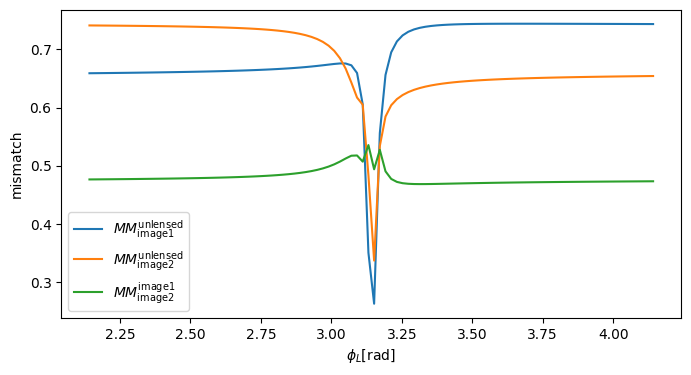

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(phi_Ls, mismatches_unlensed_image_1, label=r"$MM^{\rm unlensed}_{\rm image 1}$")
ax.plot(phi_Ls, mismatches_unlensed_image_2, label=r"$MM^{\rm unlensed}_{\rm image 2}$")
ax.plot(phi_Ls, mismatches_image1_image_2, label=r"$MM^{\rm image 1}_{\rm image 2}$")
ax.set_xlabel(r"$\phi_L[\rm rad]$")
ax.set_ylabel("mismatch")
ax.legend()
plt.savefig("phi_L_MM")